# Feature Selection in Image Analysis using Particle Swarm Optimisation (PSO)

---

## Problem Statement

This notebook implements **Particle Swarm Optimisation (PSO)** as a second Swarm Intelligence (SI) algorithm for feature selection, complementing the Genetic Algorithm (GA)

Modern image analysis pipelines extract **high-dimensional feature vectors** by combining multiple descriptors:
- **HOG (Histogram of Oriented Gradients):** Captures edge/shape structure via gradient orientations in localised image patches.
- **LBP (Local Binary Patterns):** Captures texture information by thresholding pixel neighbourhoods.

Combining descriptors improves representational power but introduces the **curse of dimensionality**:
- Model training time increases dramatically
- Irrelevant/redundant features add noise and hurt generalisation
- Memory and inference costs become prohibitive
- Overfitting risk increases, especially with limited data

## PSO Approach

**Particle Swarm Optimisation** is a population-based SI metaheuristic that models a swarm of particles navigating the search space, guided by their own best-known position and the swarm's global best position.

For **binary feature selection**, each particle carries:
- A **position vector** `x ∈ ℝⁿ` (continuous velocities)
- A **binary mask** derived from `x` via a sigmoid transfer function (S-shaped or V-shaped)
- A **velocity vector** `v ∈ ℝⁿ` updated each iteration
- Personal best `pbest` and global best `gbest` memories

A **Support Vector Machine (SVM)** acts as the fitness evaluator.

The fitness function balances **accuracy** vs **feature reduction**:
```
fitness = alpha * accuracy + (1 - alpha) * (1 - selected_ratio)
```
where `alpha = 0.9` prioritises accuracy and `(1-alpha) = 0.1` rewards compactness.

---

## Experiments

| Experiment | Variable                  | Fixed                              |
|------------|---------------------------|------------------------------------|
| **EXP-P1** | Transfer function         | S-shaped vs V-shaped               |
| **EXP-P2** | Topology (neighbourhood)  | gbest (global) vs lbest (ring)     |
| **EXP-P3** | Inertia weight strategy   | fixed vs linear decay vs random    |
| **EXP-P4** | Initialisation strategy   | random sparse vs uniform           |

Each experiment runs **30 seeds** (42–71), mirrors the GA notebook format, and produces convergence curves + accuracy bar charts.

---

**Goal:** Find a compact feature subset that matches or exceeds baseline SVM performance on all features.


---
## 1. Imports, Global Configuration & Reproducibility


In [1]:
# ============================================================
# Cell 1: Import all required libraries and configure globals.
# Sets numpy random seed for full reproducibility.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import time

from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from tqdm import tqdm

# ── Global settings ──────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
})
sns.set_style('whitegrid')

# ── Output directory for saved figures ──────────────────────
os.makedirs('figures_pso', exist_ok=True)

print("All imports successful.")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")
print(f"   Random seed set to: {RANDOM_SEED}")

All imports successful.
   NumPy  : 2.0.2
   Pandas : 2.2.2
   Random seed set to: 42


---
## 2. Data Loading & Exploration


In [3]:
# ============================================================
# Cell 2: Load pre-extracted HOG+LBP feature arrays from disk.
# Prints shapes, number of classes, and class distribution.
# ============================================================

X = np.load('XPCA_features_80.npy')
y = np.load('y_labels.npy')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Feature matrix shape  : {X.shape}  (samples , features)")
print(f"Label vector shape    : {y.shape}")
print(f"Total samples         : {X.shape[0]}")
print(f"Total features        : {X.shape[1]}")

# ── Class information ────────────────────────────────────────
unique_classes, class_counts = np.unique(y, return_counts=True)
n_classes = len(unique_classes)
print(f"\nNumber of classes     : {n_classes}")
print(f"Class labels          : {unique_classes}")
print("\nClass distribution:")
for cls, cnt in zip(unique_classes, class_counts):
    pct = cnt / len(y) * 100
    print(f"   Class {cls:>3}  →  {cnt:>5} samples  ({pct:.1f}%)")

# ── Feature statistics ───────────────────────────────────────
print(f"\nFeature value range   : [{X.min():.4f}, {X.max():.4f}]")
print(f"Feature mean          : {X.mean():.4f}")
print(f"Feature std           : {X.std():.4f}")

# ── Check for NaN / Inf ──────────────────────────────────────
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f"\nNaN values            : {nan_count}")
print(f"Inf values            : {inf_count}")
if nan_count == 0 and inf_count == 0:
    print("Data is clean — no NaN or Inf values.")

DATASET OVERVIEW
Feature matrix shape  : (4844, 700)  (samples , features)
Label vector shape    : (4844,)
Total samples         : 4844
Total features        : 700

Number of classes     : 3
Class labels          : [0 1 2]

Class distribution:
   Class   0  →   1603 samples  (33.1%)
   Class   1  →   1603 samples  (33.1%)
   Class   2  →   1638 samples  (33.8%)

Feature value range   : [-49.4303, 53.7179]
Feature mean          : -0.0000
Feature std           : 3.0449

NaN values            : 0
Inf values            : 0
Data is clean — no NaN or Inf values.


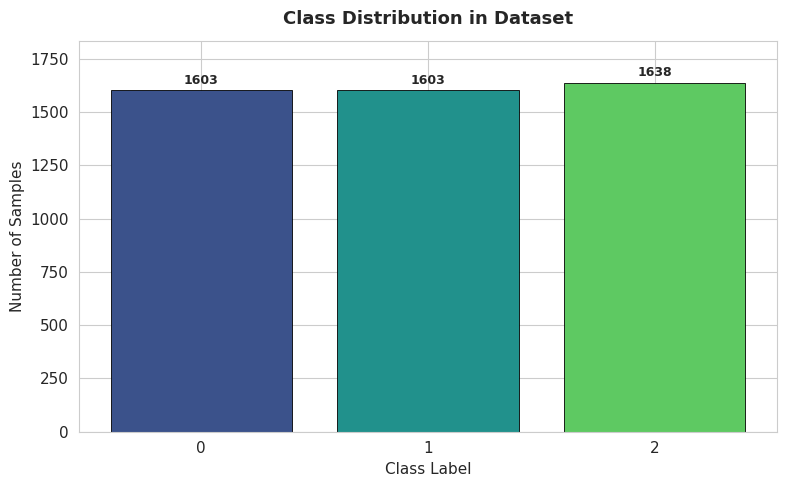

Figure saved : figures_pso/class_distribution.png


In [4]:
# ============================================================
# Cell 3: Visualise class distribution as a bar chart.
# ============================================================

fig, ax = plt.subplots(figsize=(max(8, n_classes * 0.7), 5))

colors = sns.color_palette('viridis', n_classes)
bars = ax.bar(unique_classes.astype(str), class_counts, color=colors, edgecolor='black', linewidth=0.6)

for bar, cnt in zip(bars, class_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(class_counts) * 0.01,
        str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Class Distribution in Dataset', fontweight='bold', pad=12)
ax.set_xlabel('Class Label')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(class_counts) * 1.12)
plt.tight_layout()
plt.savefig('figures_pso/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved : figures_pso/class_distribution.png")

In [5]:
# ============================================================
# Cell 4: Split data 80/20 train/test with stratification.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training samples  : {X_train.shape[0]}  ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test samples      : {X_test.shape[0]}   ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Feature dimension : {X_train.shape[1]}")
print("\nTrain class counts:")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"   Class {cls}: {cnt}")
print("\nTest class counts:")
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f"   Class {cls}: {cnt}")

TRAIN / TEST SPLIT
Training samples  : 3875  (80.0%)
Test samples      : 969   (20.0%)
Feature dimension : 700

Train class counts:
   Class 0: 1282
   Class 1: 1283
   Class 2: 1310

Test class counts:
   Class 0: 321
   Class 1: 320
   Class 2: 328


---
## 3. Baseline SVM (No Feature Selection)


Training baseline SVM on ALL features...

BASELINE SVM RESULTS
Features used         : 700  (all features)
Test Accuracy         : 0.8308  (83.08%)
Weighted F1-Score     : 0.8293
Training time         : 7.2s

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       321
           1       0.80      0.72      0.76       320
           2       0.89      0.92      0.90       328

    accuracy                           0.83       969
   macro avg       0.83      0.83      0.83       969
weighted avg       0.83      0.83      0.83       969



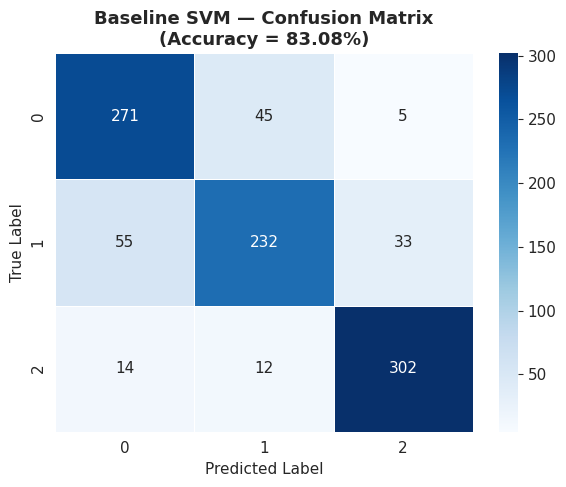

Figure saved → figures_pso/baseline_confusion_matrix.png


In [6]:
# ============================================================
# Cell 5: Train a baseline SVM on all features.
# Reports accuracy, F1 score, classification report,
# and confusion matrix.  This benchmark is used for comparison.
# ============================================================

print("Training baseline SVM on ALL features...")
t0 = time.time()

baseline_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
baseline_svm.fit(X_train, y_train)
y_pred_baseline = baseline_svm.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1       = f1_score(y_test, y_pred_baseline, average='weighted')
elapsed           = time.time() - t0

print("\n" + "=" * 50)
print("BASELINE SVM RESULTS")
print("=" * 50)
print(f"Features used         : {X_train.shape[1]}  (all features)")
print(f"Test Accuracy         : {baseline_accuracy:.4f}  ({baseline_accuracy*100:.2f}%)")
print(f"Weighted F1-Score     : {baseline_f1:.4f}")
print(f"Training time         : {elapsed:.1f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes - 1)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=unique_classes, yticklabels=unique_classes,
    linewidths=0.5, ax=ax
)
ax.set_title(f'Baseline SVM — Confusion Matrix\n(Accuracy = {baseline_accuracy*100:.2f}%)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('figures_pso/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures_pso/baseline_confusion_matrix.png")

---
## 4. PSO Core Implementation

### 4.1 EA Component Definitions (Requirement d)

| Component | PSO Definition |
|---|---|
| **Representation** | Each particle `i` has a continuous position vector `x_i ∈ ℝⁿ` and a binary mask derived by a transfer function. `1` = feature selected, `0` = excluded. |
| **Population** | Swarm of `SWARM_SIZE` particles, each independently initialised. |
| **Evaluation (Fitness)** | `fitness = α·accuracy + (1−α)·(1 − n_selected/n_total)`. SVM with 2-fold CV on training data only. |
| **Velocity Update** | `v ← w·v + c1·r1·(pbest−x) + c2·r2·(gbest−x)` |
| **Position Update** | Continuous positions updated; binary mask derived via transfer function. |
| **Personal/Global Best** | Each particle tracks its own best; swarm tracks global best (`gbest`). |
| **Inertia Weight `w`** | Controls exploration/exploitation trade-off (see EXP-P3). |
| **Cognitive coeff `c1`** | Pull towards particle's own best position. |
| **Social coeff `c2`** | Pull towards swarm's global best position. |
| **Termination** | Max iterations reached **or** early stopping (no improvement for `patience` iterations). |
| **Constraint Handling** | `MIN_FEATURES` enforced: if binary mask has fewer than `MIN_FEATURES` selected, randomly activate bits (Repair Function). |
| **Diversity Preservation** | Velocity clamping (`v_max`), random reinitialisation of stagnant particles, lbest topology (ring neighbourhood). |


In [7]:
# ============================================================
# Cell 7: PSO hyper-parameters — defined once as constants.
# ============================================================

N_FEATURES       = X_train.shape[1]
SWARM_SIZE       = 20           # number of particles
N_ITERATIONS     = 15           # max iterations
N_RUNS           = 30           # runs per configuration
SEEDS            = list(range(42, 72))   # 30 seeds: 42–71

# PSO velocity / position bounds
V_MAX            = 4.0          # velocity clamp: prevents bit-flip saturation
X_MIN, X_MAX     = -10.0, 10.0  # position bounds for transfer function

# Cognitive / social coefficients
C1               = 2.0          # cognitive (personal best) coefficient
C2               = 2.0          # social (global best) coefficient

# Default inertia weight (fixed baseline)
W_DEFAULT        = 0.7

# Fitness
ALPHA            = 0.9          # accuracy vs compactness weight
MIN_FEATURES     = 10           # minimum selected features (constraint)

# Initialisation
INIT_FEAT_PROB   = 0.3          # probability of feature=1 in sparse init

# Early stopping
EARLY_STOPPING_PATIENCE = 8

# Stagnation reinitialisation
STAGNATION_LIMIT = 5            # reinitialise particle after this many iters of no improvement

print("=" * 50)
print("PSO HYPER-PARAMETERS")
print("=" * 50)
params = {
    'Total features'          : N_FEATURES,
    'Swarm size'              : SWARM_SIZE,
    'Max iterations'          : N_ITERATIONS,
    'Runs per config'         : N_RUNS,
    'Seeds'                   : '42–71 (30 seeds)',
    'V_max (velocity clamp)'  : V_MAX,
    'Position bounds'         : f'[{X_MIN}, {X_MAX}]',
    'c1 (cognitive)'          : C1,
    'c2 (social)'             : C2,
    'w (default inertia)'     : W_DEFAULT,
    'Alpha (fitness)'         : ALPHA,
    'Min features (constraint)': MIN_FEATURES,
    'Init feature prob'       : INIT_FEAT_PROB,
    'Early stopping patience' : EARLY_STOPPING_PATIENCE,
    'Stagnation limit'        : STAGNATION_LIMIT,
}
for k, v in params.items():
    print(f"   {k:<30}: {v}")

PSO HYPER-PARAMETERS
   Total features                : 700
   Swarm size                    : 20
   Max iterations                : 15
   Runs per config               : 30
   Seeds                         : 42–71 (30 seeds)
   V_max (velocity clamp)        : 4.0
   Position bounds               : [-10.0, 10.0]
   c1 (cognitive)                : 2.0
   c2 (social)                   : 2.0
   w (default inertia)           : 0.7
   Alpha (fitness)               : 0.9
   Min features (constraint)     : 10
   Init feature prob             : 0.3
   Early stopping patience       : 8
   Stagnation limit              : 5


In [8]:
# ============================================================
# Cell 8: TRANSFER FUNCTIONS  (Requirement e — variation)
#
# Transfer functions map a continuous position value x to a
# probability of the corresponding binary bit being 1.
#
# Two families are implemented:
#   S-shaped (sigmoid):  T(x) = 1 / (1 + exp(-x))
#   V-shaped (tanh):     T(x) = |tanh(x/2)|
#
# For S-shaped: bit = 1 if rand() < T(x), else 0
# For V-shaped: bit flips if rand() < T(x)
# ============================================================

def sigmoid(x):
    """S-shaped sigmoid transfer function.  Clips x for numerical safety."""
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

def v_shaped(x):
    """V-shaped transfer function based on tanh.  Returns values in [0, 1]."""
    return np.abs(np.tanh(x / 2.0))

def apply_transfer(position, current_binary, transfer_type='sigmoid'):
    """
    Map continuous position to a binary vector using a transfer function.

    Parameters
    ----------
    position      : np.ndarray  Continuous position vector of shape (n_features,).
    current_binary: np.ndarray  Current binary mask (needed for V-shaped flip logic).
    transfer_type : str         'sigmoid' (S-shaped) | 'vshaped' (V-shaped).

    Returns
    -------
    binary : np.ndarray  Updated binary mask.
    """
    n = len(position)
    binary = current_binary.copy()

    if transfer_type == 'sigmoid':
        prob = sigmoid(position)
        binary = (np.random.rand(n) < prob).astype(int)

    elif transfer_type == 'vshaped':
        prob = v_shaped(position)
        flip_mask = np.random.rand(n) < prob
        binary = binary.copy()
        binary[flip_mask] ^= 1   # XOR-flip selected bits

    else:
        raise ValueError(f"Unknown transfer function: '{transfer_type}'. Use 'sigmoid' or 'vshaped'.")

    # ── Repair: enforce MIN_FEATURES (Requirement b) ─────────
    n_sel = binary.sum()
    if n_sel < MIN_FEATURES:
        zero_idx = np.where(binary == 0)[0]
        need     = MIN_FEATURES - n_sel
        activate = np.random.choice(zero_idx, need, replace=False)
        binary[activate] = 1

    return binary


# Sanity check
_pos = np.random.randn(N_FEATURES) * 2
_bin = np.zeros(N_FEATURES, dtype=int)
_s = apply_transfer(_pos, _bin, 'sigmoid')
_v = apply_transfer(_pos, _bin, 'vshaped')
print(f"Transfer function test:")
print(f"  sigmoid  → selected: {_s.sum()}  (min {MIN_FEATURES} enforced)")
print(f"  vshaped  → selected: {_v.sum()}  (min {MIN_FEATURES} enforced)")
del _pos, _bin, _s, _v

print("\nTransfer functions defined:")
print("  sigmoid(x)   = 1/(1+exp(-x))   →  P(bit=1)")
print("  v_shaped(x)  = |tanh(x/2)|     →  P(bit flips)")

Transfer function test:
  sigmoid  → selected: 339  (min 10 enforced)
  vshaped  → selected: 391  (min 10 enforced)

Transfer functions defined:
  sigmoid(x)   = 1/(1+exp(-x))   →  P(bit=1)
  v_shaped(x)  = |tanh(x/2)|     →  P(bit flips)


In [9]:
# ============================================================
# Cell 9: INITIALISATION STRATEGIES  (Bonus: 2 init approaches)
#
# Strategy 1 — Sparse Random (mirrors GA notebook):
#   Each bit set to 1 with probability INIT_FEAT_PROB (0.3).
#   Results in ~30% feature density on average.
#
# Strategy 2 — Uniform Random:
#   Each bit set to 1 with probability 0.5.
#   Denser, less biased starting point.
#
# Continuous positions are initialised to match the binary mask
# via inverse sigmoid so sigmoid(x) ≈ mask.
# Velocities are initialised uniformly in [-V_MAX/2, V_MAX/2].
# ============================================================

def initialise_swarm(swarm_size, n_features, init_strategy='sparse'):
    """
    Initialise a PSO swarm.

    Parameters
    ----------
    swarm_size    : int
    n_features    : int
    init_strategy : str   'sparse' (p=0.3) | 'uniform' (p=0.5)

    Returns
    -------
    positions  : np.ndarray  (swarm_size, n_features)  continuous
    velocities : np.ndarray  (swarm_size, n_features)  continuous
    binary     : np.ndarray  (swarm_size, n_features)  int {0,1}
    """
    p = INIT_FEAT_PROB if init_strategy == 'sparse' else 0.5

    binary = (np.random.rand(swarm_size, n_features) < p).astype(int)

    # Enforce MIN_FEATURES per particle
    for i in range(swarm_size):
        if binary[i].sum() < MIN_FEATURES:
            idx = np.random.choice(n_features, MIN_FEATURES, replace=False)
            binary[i] = 0
            binary[i, idx] = 1

    # Initialise continuous positions consistent with the binary mask.
    # Use logit(p_init) so sigmoid(position) ≈ binary on average.
    positions = np.where(
        binary == 1,
        np.random.uniform(0.5, 2.0, (swarm_size, n_features)),    # positive side
        np.random.uniform(-2.0, -0.5, (swarm_size, n_features))   # negative side
    )

    # Velocities: small random values
    velocities = np.random.uniform(-V_MAX / 2, V_MAX / 2, (swarm_size, n_features))

    return positions, velocities, binary


# Sanity check
_pos, _vel, _bin = initialise_swarm(10, N_FEATURES, 'sparse')
print("Initialisation test (sparse):")
print(f"  positions  shape : {_pos.shape}")
print(f"  velocities shape : {_vel.shape}")
print(f"  binary     shape : {_bin.shape}")
print(f"  features per particle (min/mean/max): "
      f"{_bin.sum(1).min()} / {_bin.sum(1).mean():.1f} / {_bin.sum(1).max()}")
print(f"  min >= {MIN_FEATURES}: {_bin.sum(1).min() >= MIN_FEATURES}")
del _pos, _vel, _bin

print("\nInitialisation strategies defined:")
print("  'sparse'  — P(bit=1) = 0.3  (30% density)")
print("  'uniform' — P(bit=1) = 0.5  (50% density)")

Initialisation test (sparse):
  positions  shape : (10, 700)
  velocities shape : (10, 700)
  binary     shape : (10, 700)
  features per particle (min/mean/max): 203 / 212.9 / 225
  min >= 10: True

Initialisation strategies defined:
  'sparse'  — P(bit=1) = 0.3  (30% density)
  'uniform' — P(bit=1) = 0.5  (50% density)


In [10]:
# ============================================================
# Cell 10: FITNESS FUNCTION
# Identical in form to the GA notebook for fair cross-algorithm
# comparison.  Never touches the test set during evolution.
# ============================================================

def evaluate_particle(binary_mask, X_tr, y_tr, alpha=ALPHA):
    """
    Compute the fitness of a single binary particle.

    Fitness = alpha * accuracy + (1 - alpha) * (1 - n_selected / n_total)

    Parameters
    ----------
    binary_mask : np.ndarray  Binary mask of length n_features.
    X_tr        : np.ndarray  Training feature matrix.
    y_tr        : np.ndarray  Training labels.
    alpha       : float       Accuracy weight.

    Returns
    -------
    fitness  : float
    accuracy : float  CV accuracy on training data.
    n_sel    : int    Number of selected features.
    """
    selected_idx = np.where(binary_mask == 1)[0]
    n_sel = len(selected_idx)

    if n_sel < MIN_FEATURES:
        return 0.0, 0.0, n_sel

    X_sub = X_tr[:, selected_idx]

    # LinearSVC for fast CV during PSO evaluation (no test leakage)
    svm = LinearSVC(C=1.0, random_state=RANDOM_SEED, max_iter=1000)
    cv_scores = cross_val_score(svm, X_sub, y_tr, cv=2, scoring='accuracy', n_jobs=-1)
    accuracy = cv_scores.mean()

    n_total = len(binary_mask)
    fitness = alpha * accuracy + (1.0 - alpha) * (1.0 - n_sel / n_total)

    return fitness, accuracy, n_sel


print("evaluate_particle() defined.")
print("Formula: fitness = alpha * accuracy + (1 - alpha) * (1 - n_sel / n_total)")
print(f"Alpha = {ALPHA}  (accuracy: {ALPHA*100:.0f}%  |  compactness: {(1-ALPHA)*100:.0f}%)")
print("Evaluation uses 2-fold CV on training data ONLY — test set never touched during PSO.")

evaluate_particle() defined.
Formula: fitness = alpha * accuracy + (1 - alpha) * (1 - n_sel / n_total)
Alpha = 0.9  (accuracy: 90%  |  compactness: 10%)
Evaluation uses 2-fold CV on training data ONLY — test set never touched during PSO.


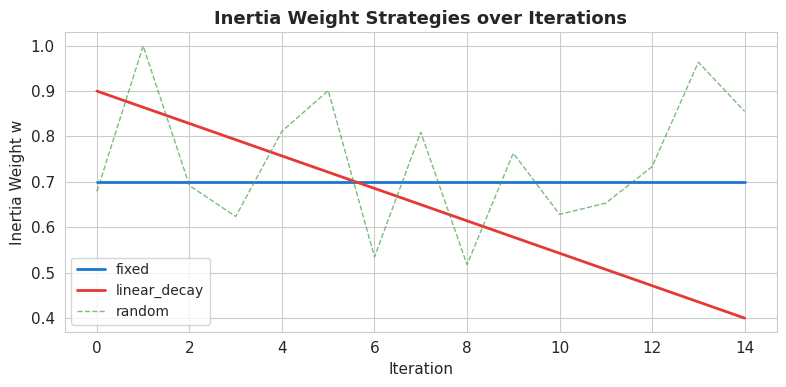

Figure saved → figures_pso/inertia_strategies.png

Inertia weight strategies defined:
  'fixed'        — w constant at W_DEFAULT
  'linear_decay' — w decreases linearly from 0.9 → 0.4
  'random'       — w ~ U[0.5, 1.0] each iteration


In [11]:
# ============================================================
# Cell 11: INERTIA WEIGHT STRATEGIES  (Requirement g — parameter control)
#
# Three strategies for controlling the inertia weight w:
#
#   'fixed'        — constant w = W_DEFAULT throughout.
#   'linear_decay' — w decreases linearly from w_max to w_min
#                    over the total number of iterations.
#   'random'       — w sampled uniformly from [0.5, 1.0] each iter.
#
# Higher w → more exploration.  Lower w → more exploitation.
# Linear decay is the most widely used adaptive strategy.
# ============================================================

def get_inertia_weight(iteration, n_iterations, strategy='fixed',
                        w_fixed=W_DEFAULT, w_max=0.9, w_min=0.4):
    """
    Return the inertia weight for the current iteration.

    Parameters
    ----------
    iteration    : int   Current iteration (0-indexed).
    n_iterations : int   Maximum number of iterations.
    strategy     : str   'fixed' | 'linear_decay' | 'random'.
    w_fixed      : float Constant weight (used by 'fixed').
    w_max        : float Starting weight for linear decay.
    w_min        : float Ending weight for linear decay.

    Returns
    -------
    w : float
    """
    if strategy == 'fixed':
        return w_fixed

    elif strategy == 'linear_decay':
        # Linearly interpolate from w_max to w_min
        t = iteration / max(n_iterations - 1, 1)
        return w_max - t * (w_max - w_min)

    elif strategy == 'random':
        return np.random.uniform(0.5, 1.0)

    else:
        raise ValueError(f"Unknown inertia strategy: '{strategy}'.")


# Visualise how w changes over iterations for each strategy
_iters = np.arange(N_ITERATIONS)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(_iters, [get_inertia_weight(i, N_ITERATIONS, 'fixed')        for i in _iters],
        label='fixed',        color='#1976D2', linewidth=2)
ax.plot(_iters, [get_inertia_weight(i, N_ITERATIONS, 'linear_decay') for i in _iters],
        label='linear_decay', color='#E53935', linewidth=2)
ax.plot(_iters, [get_inertia_weight(i, N_ITERATIONS, 'random')       for i in _iters],
        label='random',       color='#43A047', linewidth=1, alpha=0.7, linestyle='--')
ax.set_title('Inertia Weight Strategies over Iterations', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Inertia Weight w')
ax.legend()
plt.tight_layout()
plt.savefig('figures_pso/inertia_strategies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures_pso/inertia_strategies.png")
del _iters

print("\nInertia weight strategies defined:")
print("  'fixed'        — w constant at W_DEFAULT")
print("  'linear_decay' — w decreases linearly from 0.9 → 0.4")
print("  'random'       — w ~ U[0.5, 1.0] each iteration")

In [12]:
# ============================================================
# Cell 12: TOPOLOGY / NEIGHBOURHOOD  (Requirement h — diversity)
#
# Two topologies control which particles influence each other:
#
#   'gbest'  — Global best (fully connected):
#              Every particle is attracted to the single best
#              position found by ANY particle in the swarm.
#              Fast convergence, lower diversity.
#
#   'lbest'  — Local best (ring neighbourhood):
#              Each particle is attracted to the best position
#              found within its k nearest neighbours (ring, k=2).
#              Slower convergence, higher diversity (niching effect).
#
# lbest acts as the PSO-native diversity preservation mechanism.
# ============================================================

def get_social_best(particle_idx, pbest_positions, pbest_fitness,
                     topology='gbest', ring_k=2):
    """
    Return the social best position for particle `particle_idx`.

    Parameters
    ----------
    particle_idx    : int
    pbest_positions : np.ndarray  (swarm_size, n_features)  personal best positions.
    pbest_fitness   : np.ndarray  (swarm_size,)             personal best fitness values.
    topology        : str         'gbest' | 'lbest'
    ring_k          : int         Neighbours on each side for lbest ring.

    Returns
    -------
    social_best_pos : np.ndarray  Position to attract particle towards.
    """
    swarm_size = len(pbest_fitness)

    if topology == 'gbest':
        best_idx = np.argmax(pbest_fitness)
        return pbest_positions[best_idx].copy()

    elif topology == 'lbest':
        # Build ring neighbourhood: particle_idx ± ring_k (wrapping)
        neighbours = [(particle_idx + j) % swarm_size
                      for j in range(-ring_k, ring_k + 1)]
        best_in_neighbourhood = neighbours[np.argmax(pbest_fitness[neighbours])]
        return pbest_positions[best_in_neighbourhood].copy()

    else:
        raise ValueError(f"Unknown topology: '{topology}'. Use 'gbest' or 'lbest'.")


print("Topology functions defined:")
print("  'gbest' — global best (all particles share one attractor)")
print("  'lbest' — local best ring (k=2 neighbours each side)")
print("\nDiversity mechanism: lbest topology + velocity clamping + stagnation reinitialisation")

Topology functions defined:
  'gbest' — global best (all particles share one attractor)
  'lbest' — local best ring (k=2 neighbours each side)

Diversity mechanism: lbest topology + velocity clamping + stagnation reinitialisation


In [13]:
# ============================================================
# Cell 13: VELOCITY & POSITION UPDATE
#
# Standard PSO update equations:
#   v_i(t+1) = w*v_i(t) + c1*r1*(pbest_i - x_i(t)) + c2*r2*(social_best - x_i(t))
#   x_i(t+1) = x_i(t) + v_i(t+1)
#
# Velocity clamping: v clipped to [-V_MAX, V_MAX]
# Position clamping: x clipped to [X_MIN, X_MAX]
#
# Binary mask updated by applying the chosen transfer function.
# ============================================================

def update_particle(position, velocity, binary, pbest_pos, social_best_pos,
                    w, c1=C1, c2=C2, transfer_type='sigmoid'):
    """
    Perform one PSO velocity and position update for a single particle.

    Parameters
    ----------
    position        : np.ndarray  Current continuous position (n_features,).
    velocity        : np.ndarray  Current velocity (n_features,).
    binary          : np.ndarray  Current binary mask (n_features,).
    pbest_pos       : np.ndarray  Personal best position (n_features,).
    social_best_pos : np.ndarray  Social best position (n_features,).
    w               : float       Inertia weight.
    c1, c2          : float       Cognitive and social coefficients.
    transfer_type   : str         'sigmoid' | 'vshaped'.

    Returns
    -------
    new_pos    : np.ndarray  Updated continuous position.
    new_vel    : np.ndarray  Updated velocity.
    new_binary : np.ndarray  Updated binary mask.
    """
    n = len(position)
    r1 = np.random.rand(n)
    r2 = np.random.rand(n)

    # Velocity update
    cognitive_component = c1 * r1 * (pbest_pos - position)
    social_component    = c2 * r2 * (social_best_pos - position)
    new_vel = w * velocity + cognitive_component + social_component

    # Velocity clamping (diversity preservation via exploration control)
    new_vel = np.clip(new_vel, -V_MAX, V_MAX)

    # Position update
    new_pos = position + new_vel
    new_pos = np.clip(new_pos, X_MIN, X_MAX)

    # Binarisation via transfer function
    new_binary = apply_transfer(new_pos, binary, transfer_type)

    return new_pos, new_vel, new_binary


print("update_particle() defined.")
print("  v(t+1) = w*v(t) + c1*r1*(pbest - x) + c2*r2*(social_best - x)")
print("  x(t+1) = x(t) + v(t+1)  [clipped to position bounds]")
print(f"  Velocity clamping: [-{V_MAX}, {V_MAX}]")
print(f"  Position bounds  : [{X_MIN}, {X_MAX}]")

update_particle() defined.
  v(t+1) = w*v(t) + c1*r1*(pbest - x) + c2*r2*(social_best - x)
  x(t+1) = x(t) + v(t+1)  [clipped to position bounds]
  Velocity clamping: [-4.0, 4.0]
  Position bounds  : [-10.0, 10.0]


In [14]:
# ============================================================
# Cell 14: STAGNATION REINITIALISATION  (Diversity preservation)
#
# If a particle's personal best fitness has not improved for
# STAGNATION_LIMIT consecutive iterations, reinitialise that
# particle's position and velocity (but keep the global best).
#
# This prevents premature convergence by injecting new diversity
# when particles become stuck in local optima.
# ============================================================

def reinitialise_particle(n_features, init_strategy='sparse'):
    """
    Reinitialise a single stagnant particle.

    Returns
    -------
    pos    : np.ndarray  New continuous position  (n_features,).
    vel    : np.ndarray  New velocity              (n_features,).
    binary : np.ndarray  New binary mask           (n_features,).
    """
    p = INIT_FEAT_PROB if init_strategy == 'sparse' else 0.5
    binary = (np.random.rand(n_features) < p).astype(int)
    if binary.sum() < MIN_FEATURES:
        idx = np.random.choice(n_features, MIN_FEATURES, replace=False)
        binary = np.zeros(n_features, dtype=int)
        binary[idx] = 1

    pos = np.where(
        binary == 1,
        np.random.uniform(0.5, 2.0, n_features),
        np.random.uniform(-2.0, -0.5, n_features)
    )
    vel = np.random.uniform(-V_MAX / 2, V_MAX / 2, n_features)
    return pos, vel, binary


print("reinitialise_particle() defined.")
print(f"Stagnation limit: {STAGNATION_LIMIT} iterations without personal-best improvement.")
print("Reinitialised particle gets a fresh random position and velocity.")
print("Global best (gbest) is NEVER erased — reinitialisation is diversity injection only.")

reinitialise_particle() defined.
Stagnation limit: 5 iterations without personal-best improvement.
Reinitialised particle gets a fresh random position and velocity.
Global best (gbest) is NEVER erased — reinitialisation is diversity injection only.


In [15]:
# ============================================================
# Cell 15: MAIN PSO RUN FUNCTION
# Ties together: initialisation → fitness evaluation →
# velocity/position update → personal/global best tracking →
# stagnation reinitialisation → early stopping.
# ============================================================

def run_pso(
    swarm_size              = SWARM_SIZE,
    n_iterations            = N_ITERATIONS,
    transfer_type           = 'sigmoid',
    topology                = 'gbest',
    inertia_strategy        = 'fixed',
    init_strategy           = 'sparse',
    alpha                   = ALPHA,
    X_tr                    = None,
    y_tr                    = None,
    verbose                 = False,
    early_stopping_patience = EARLY_STOPPING_PATIENCE,
):
    """
    Run the Binary PSO for feature selection.

    Parameters
    ----------
    swarm_size              : int
    n_iterations            : int
    transfer_type           : str   'sigmoid' | 'vshaped'
    topology                : str   'gbest'   | 'lbest'
    inertia_strategy        : str   'fixed'   | 'linear_decay' | 'random'
    init_strategy           : str   'sparse'  | 'uniform'
    alpha                   : float Accuracy vs compactness weight.
    X_tr, y_tr              : Training data (defaults to X_train, y_train).
    verbose                 : bool
    early_stopping_patience : int

    Returns
    -------
    gbest_binary    : np.ndarray   Best binary feature mask.
    fitness_history : list[float]  Best fitness per iteration.
    accuracy_history: list[float]  Best CV accuracy per iteration.
    best_accuracy   : float        CV accuracy of best position.
    n_features_sel  : int          Features selected by best position.
    runtime_seconds : float
    """
    if X_tr is None:
        X_tr = X_train
    if y_tr is None:
        y_tr = y_train

    n_features = X_tr.shape[1]
    start_time = time.time()

    # ── Initialise swarm ─────────────────────────────────────
    positions, velocities, binaries = initialise_swarm(swarm_size, n_features, init_strategy)

    # Evaluate initial fitness
    fitnesses  = np.zeros(swarm_size)
    accuracies = np.zeros(swarm_size)
    n_sel_arr  = np.zeros(swarm_size, dtype=int)

    for i in range(swarm_size):
        f, acc, n = evaluate_particle(binaries[i], X_tr, y_tr, alpha)
        fitnesses[i]  = f
        accuracies[i] = acc
        n_sel_arr[i]  = n

    # Personal bests
    pbest_positions = positions.copy()
    pbest_fitness   = fitnesses.copy()
    pbest_binary    = binaries.copy()
    pbest_accuracy  = accuracies.copy()
    pbest_n_sel     = n_sel_arr.copy()

    # Global best
    gbest_idx      = np.argmax(pbest_fitness)
    gbest_fitness  = pbest_fitness[gbest_idx]
    gbest_binary   = pbest_binary[gbest_idx].copy()
    gbest_accuracy = pbest_accuracy[gbest_idx]
    gbest_n_sel    = pbest_n_sel[gbest_idx]

    fitness_history  = [gbest_fitness]
    accuracy_history = [gbest_accuracy]

    # Stagnation counters per particle
    stagnation_counters = np.zeros(swarm_size, dtype=int)

    # Early stopping
    no_improve_count  = 0
    prev_best_fitness = gbest_fitness

    if verbose:
        header = (f"{'Iter':>5}  {'Best Fitness':>13}  "
                  f"{'CV Accuracy':>12}  {'Features':>10}  {'Reduction':>10}")
        print(header)
        print("-" * len(header))

    # ── Main PSO loop ─────────────────────────────────────────
    for it in range(n_iterations):
        w = get_inertia_weight(it, n_iterations, inertia_strategy)

        for i in range(swarm_size):
            # Stagnation check → reinitialise if needed
            if stagnation_counters[i] >= STAGNATION_LIMIT:
                pos_new, vel_new, bin_new = reinitialise_particle(n_features, init_strategy)
                positions[i]  = pos_new
                velocities[i] = vel_new
                binaries[i]   = bin_new
                stagnation_counters[i] = 0
                continue

            # Get social attractor based on topology
            social_best = get_social_best(i, pbest_positions, pbest_fitness, topology)

            # Update position and velocity
            new_pos, new_vel, new_bin = update_particle(
                positions[i], velocities[i], binaries[i],
                pbest_positions[i], social_best,
                w, C1, C2, transfer_type
            )
            positions[i]  = new_pos
            velocities[i] = new_vel
            binaries[i]   = new_bin

            # Evaluate fitness
            f, acc, n = evaluate_particle(new_bin, X_tr, y_tr, alpha)

            # Update personal best
            if f > pbest_fitness[i]:
                pbest_positions[i] = new_pos.copy()
                pbest_fitness[i]   = f
                pbest_binary[i]    = new_bin.copy()
                pbest_accuracy[i]  = acc
                pbest_n_sel[i]     = n
                stagnation_counters[i] = 0
            else:
                stagnation_counters[i] += 1

        # Update global best
        gen_best_idx = np.argmax(pbest_fitness)
        if pbest_fitness[gen_best_idx] > gbest_fitness:
            gbest_fitness  = pbest_fitness[gen_best_idx]
            gbest_binary   = pbest_binary[gen_best_idx].copy()
            gbest_accuracy = pbest_accuracy[gen_best_idx]
            gbest_n_sel    = pbest_n_sel[gen_best_idx]

        fitness_history.append(gbest_fitness)
        accuracy_history.append(gbest_accuracy)

        # Early stopping
        if gbest_fitness > prev_best_fitness:
            no_improve_count  = 0
            prev_best_fitness = gbest_fitness
        else:
            no_improve_count += 1

        if no_improve_count >= early_stopping_patience:
            if verbose:
                print(f"\nEarly stopping triggered at iteration {it + 1}")
            break

        if verbose and (it % 5 == 0 or it == n_iterations - 1):
            reduction = (1 - gbest_n_sel / n_features) * 100
            print(f"{it+1:>5}  {gbest_fitness:>13.4f}  "
                  f"{gbest_accuracy:>11.4f}  "
                  f"{gbest_n_sel:>8}  "
                  f"{reduction:>9.1f}%")

    runtime_seconds = time.time() - start_time

    if verbose:
        reduction = (1 - gbest_n_sel / n_features) * 100
        print(f"  PSO done | fitness={gbest_fitness:.4f} | acc={gbest_accuracy:.4f} | "
              f"features={gbest_n_sel} | {runtime_seconds:.1f}s")

    return (gbest_binary, fitness_history, accuracy_history,
            gbest_accuracy, gbest_n_sel, runtime_seconds)


print("run_pso() defined.")
print("  Returns: gbest_binary, fitness_history, accuracy_history, cv_acc, n_feat, runtime_seconds")
print("  Diversity: velocity clamping + lbest topology + stagnation reinitialisation")

run_pso() defined.
  Returns: gbest_binary, fitness_history, accuracy_history, cv_acc, n_feat, runtime_seconds
  Diversity: velocity clamping + lbest topology + stagnation reinitialisation


In [16]:
# ============================================================
# Cell 16: HELPER — evaluate best particle on held-out TEST set.
# Called AFTER evolution, never during.
# ============================================================

def evaluate_on_test(binary_mask, X_tr, y_tr, X_te, y_te):
    """
    Retrain SVM with selected features on the full training set
    and evaluate on the held-out test set.

    This is the ONLY point at which X_test is used.

    Parameters
    ----------
    binary_mask : np.ndarray  Binary feature mask.
    X_tr, y_tr  : Training data.
    X_te, y_te  : Test data.

    Returns
    -------
    test_accuracy : float
    n_selected    : int
    reduction_pct : float
    """
    selected_idx  = np.where(binary_mask == 1)[0]
    n_selected    = len(selected_idx)
    n_total       = len(binary_mask)
    reduction_pct = (1 - n_selected / n_total) * 100

    X_tr_sub = X_tr[:, selected_idx]
    X_te_sub = X_te[:, selected_idx]

    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
    svm.fit(X_tr_sub, y_tr)
    y_pred = svm.predict(X_te_sub)

    test_accuracy = accuracy_score(y_te, y_pred)
    return test_accuracy, n_selected, reduction_pct


print("evaluate_on_test() helper defined.")
print("Test set is ONLY accessed here — never inside run_pso().")

evaluate_on_test() helper defined.
Test set is ONLY accessed here — never inside run_pso().


---
## 5. Experiment Infrastructure

All experiments use:
- `swarm_size = 20`, `n_iterations = 15`, `n_runs = 30`
- `seeds = range(42, 72)` — 30 seeds: 42 to 71
- `CV = 2`, `n_jobs = -1`, `early_stopping_patience = 8`

Each experiment varies **one factor only**.

| Experiment | Variable              | Fixed                                         |
|------------|-----------------------|-----------------------------------------------|
| **EXP-P1** | Transfer function     | gbest, linear_decay, sparse                   |
| **EXP-P2** | Topology              | sigmoid, linear_decay, sparse                 |
| **EXP-P3** | Inertia strategy      | sigmoid, gbest, sparse                        |
| **EXP-P4** | Init strategy         | sigmoid, gbest, linear_decay                  |


In [17]:
# ============================================================
# Cell 17: HELPER — run_pso_experiment() and summarise_experiment()
# Centralised multi-seed runner for all PSO experiments.
# ============================================================

def run_pso_experiment(
    experiment_name,
    transfer_type,
    topology,
    inertia_strategy,
    init_strategy='sparse',
    seeds=None,
    verbose=False,
):
    """
    Run PSO for every seed in `seeds` and return list of result dicts.

    Each dict contains:
        experiment_name, transfer_type, topology, inertia_strategy,
        init_strategy, seed, accuracy, fitness, num_features, runtime_seconds
    """
    if seeds is None:
        seeds = SEEDS

    rows     = []
    histories = []
    _best_acc = -1
    _best_ind = None

    for run_idx, seed in enumerate(seeds):
        print(f"  Run {run_idx+1}/{len(seeds)} | Seed: {seed}", flush=True)
        np.random.seed(seed)

        gbest_bin, hist, acc_hist, cv_acc, n_feat, runtime = run_pso(
            swarm_size              = SWARM_SIZE,
            n_iterations            = N_ITERATIONS,
            transfer_type           = transfer_type,
            topology                = topology,
            inertia_strategy        = inertia_strategy,
            init_strategy           = init_strategy,
            verbose                 = verbose,
            early_stopping_patience = EARLY_STOPPING_PATIENCE,
        )

        if cv_acc > _best_acc:
            _best_acc = cv_acc
            _best_ind = gbest_bin

        rows.append({
            'experiment_name'  : experiment_name,
            'transfer_type'    : transfer_type,
            'topology'         : topology,
            'inertia_strategy' : inertia_strategy,
            'init_strategy'    : init_strategy,
            'seed'             : seed,
            'accuracy'         : cv_acc,
            'fitness'          : hist[-1] if hist else 0.0,
            'num_features'     : n_feat,
            'runtime_seconds'  : runtime,
        })
        histories.append(hist)

    PSO_BEST_INDIVIDUALS[experiment_name] = _best_ind
    return rows, histories


def summarise_experiment(rows):
    """Return mean ± std summary dict for a list of result dicts."""
    accs  = [r['accuracy']        for r in rows]
    fits  = [r['fitness']         for r in rows]
    feats = [r['num_features']    for r in rows]
    rts   = [r['runtime_seconds'] for r in rows]
    return {
        'experiment_name'  : rows[0]['experiment_name'],
        'transfer_type'    : rows[0]['transfer_type'],
        'topology'         : rows[0]['topology'],
        'inertia_strategy' : rows[0]['inertia_strategy'],
        'init_strategy'    : rows[0]['init_strategy'],
        'accuracy_mean'    : np.mean(accs),
        'accuracy_std'     : np.std(accs),
        'fitness_mean'     : np.mean(fits),
        'fitness_std'      : np.std(fits),
        'num_features_mean': np.mean(feats),
        'num_features_std' : np.std(feats),
        'runtime_mean'     : np.mean(rts),
        'runtime_std'      : np.std(rts),
    }


def _pad_histories(hists):
    """Pad variable-length histories by repeating the final value."""
    max_len = max(len(h) for h in hists)
    return np.array([list(h) + [h[-1]] * (max_len - len(h)) for h in hists])


# Master results
PSO_ALL_RESULTS      = []
PSO_SUMMARY_ROWS     = []
PSO_BEST_INDIVIDUALS = {}   # experiment_name -> best binary mask

print("run_pso_experiment() and summarise_experiment() defined.")
print(f"Seeds: {SEEDS}  |  N_RUNS: {N_RUNS}  |  Swarm: {SWARM_SIZE}  |  Iters: {N_ITERATIONS}")

run_pso_experiment() and summarise_experiment() defined.
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]  |  N_RUNS: 30  |  Swarm: 20  |  Iters: 15


---
## 6. Experiments


=== EXP-P1: Transfer Function Comparison ===
Types: ['sigmoid', 'vshaped']  |  Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]

  Running: EXP-P1_transfer_sigmoid ...
  Run 1/30 | Seed: 42
  Run 2/30 | Seed: 43
  Run 3/30 | Seed: 44
  Run 4/30 | Seed: 45
  Run 5/30 | Seed: 46
  Run 6/30 | Seed: 47
  Run 7/30 | Seed: 48
  Run 8/30 | Seed: 49
  Run 9/30 | Seed: 50
  Run 10/30 | Seed: 51
  Run 11/30 | Seed: 52
  Run 12/30 | Seed: 53
  Run 13/30 | Seed: 54
  Run 14/30 | Seed: 55
  Run 15/30 | Seed: 56
  Run 16/30 | Seed: 57
  Run 17/30 | Seed: 58
  Run 18/30 | Seed: 59
  Run 19/30 | Seed: 60
  Run 20/30 | Seed: 61
  Run 21/30 | Seed: 62
  Run 22/30 | Seed: 63
  Run 23/30 | Seed: 64
  Run 24/30 | Seed: 65
  Run 25/30 | Seed: 66
  Run 26/30 | Seed: 67
  Run 27/30 | Seed: 68
  Run 28/30 | Seed: 69
  Run 29/30 | Seed: 70
  Run 30/30 | Seed: 71
    accuracy: 0.7143 ± 0.0105  | fitness: 0.6994 ± 0.0083  | features: 3

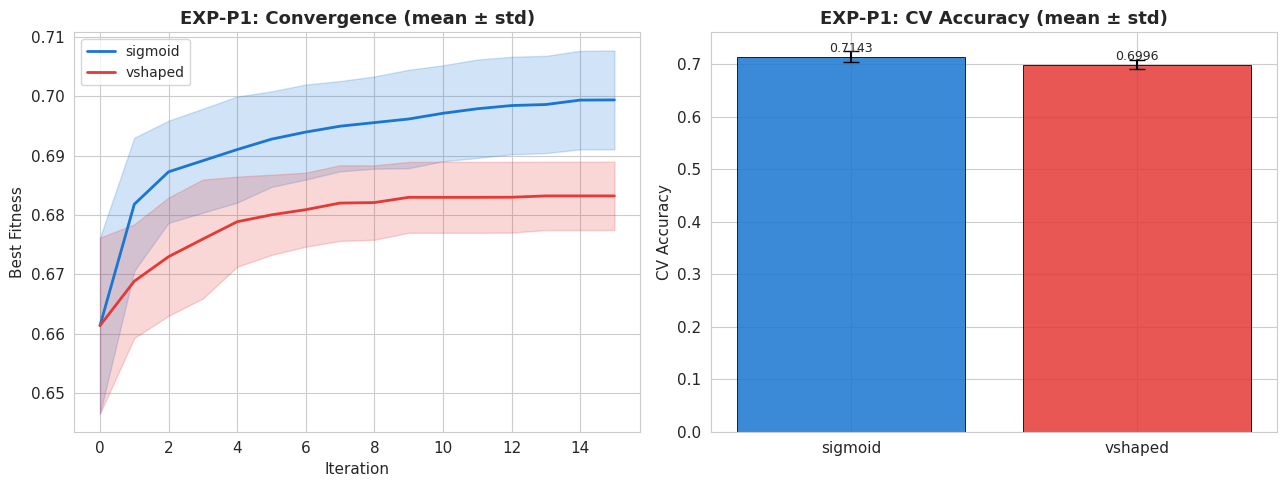

Figure saved → figures_pso/exp_p1_plots.png


In [ ]:
# ============================================================
# EXP-P1: Transfer Function Comparison
# sigmoid (S-shaped) vs vshaped (V-shaped)
# All other params fixed: gbest, linear_decay, sparse
# Mirrors EXP-A (mutation) in the GA notebook.
# ============================================================

EXP_TRANSFER_TYPES = ['sigmoid', 'vshaped']

exp_p1_rows      = []
exp_p1_histories = {}

print('=== EXP-P1: Transfer Function Comparison ===')
print(f'Types: {EXP_TRANSFER_TYPES}  |  Seeds: {SEEDS}')
print()

for tf in EXP_TRANSFER_TYPES:
    exp_name = f'EXP-P1_transfer_{tf}'
    print(f'  Running: {exp_name} ...')
    rows, hists = run_pso_experiment(
        experiment_name  = exp_name,
        transfer_type    = tf,
        topology         = 'gbest',
        inertia_strategy = 'linear_decay',
        init_strategy    = 'sparse',
    )
    exp_p1_rows.extend(rows)
    exp_p1_histories[tf] = hists
    summ = summarise_experiment(rows)
    PSO_SUMMARY_ROWS.append(summ)
    print(f'    accuracy: {summ["accuracy_mean"]:.4f} ± {summ["accuracy_std"]:.4f}  '
          f'| fitness: {summ["fitness_mean"]:.4f} ± {summ["fitness_std"]:.4f}  '
          f'| features: {summ["num_features_mean"]:.0f}  '
          f'| runtime: {summ["runtime_mean"]:.1f}s')

PSO_ALL_RESULTS.extend(exp_p1_rows)

print()
print('EXP-P1 SUMMARY — transfer_type vs accuracy_mean ± std')
print('=' * 60)
print(f'{"transfer_type":<15} {"accuracy_mean":>14} {"accuracy_std":>13} {"fitness_mean":>13}')
print('-' * 60)
for tf in EXP_TRANSFER_TYPES:
    s = next(r for r in PSO_SUMMARY_ROWS
             if r['transfer_type'] == tf and r['experiment_name'].startswith('EXP-P1'))
    print(f'{tf:<15} {s["accuracy_mean"]:>14.4f} {s["accuracy_std"]:>13.4f} {s["fitness_mean"]:>13.4f}')
print('=' * 60)

# ── Plots ────────────────────────────────────────────────────
_COLORS_P1 = {'sigmoid': '#1976D2', 'vshaped': '#E53935'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for label, hists in exp_p1_histories.items():
    arr  = _pad_histories(hists)
    iters = np.arange(arr.shape[1])
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(iters, mean, label=label, color=_COLORS_P1[label], linewidth=2)
    ax.fill_between(iters, mean - std, mean + std, alpha=0.2, color=_COLORS_P1[label])
ax.set_title('EXP-P1: Convergence (mean ± std)', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Fitness')
ax.legend()

ax = axes[1]
p1_summ = [r for r in PSO_SUMMARY_ROWS if r['experiment_name'].startswith('EXP-P1')]
labels  = [r['transfer_type'] for r in p1_summ]
means   = [r['accuracy_mean'] for r in p1_summ]
stds    = [r['accuracy_std']  for r in p1_summ]
x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=6,
              color=[_COLORS_P1.get(l, '#607D8B') for l in labels],
              edgecolor='black', linewidth=0.7, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('EXP-P1: CV Accuracy (mean ± std)', fontweight='bold')
ax.set_ylabel('CV Accuracy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures_pso/exp_p1_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures_pso/exp_p1_plots.png')

In [ ]:
# =========================
# SAVE EXP-A (ONE CELL)
# =========================

import os
import pandas as pd
import pickle
from google.colab import drive

# Mount drive
drive.mount('/content/drive')

# Path
SAVE_PATH = "/content/drive/MyDrive/PSO_Project/"
os.makedirs(SAVE_PATH, exist_ok=True)

# Save results
pd.DataFrame(PSO_ALL_RESULTS).to_csv(
    SAVE_PATH + 'progress_after_EXP_A.csv',
    index=False
)

pd.DataFrame(PSO_SUMMARY_ROWS).to_csv(
    SAVE_PATH + 'summary_after_EXP_A.csv',
    index=False
)

# Save best individuals
with open(SAVE_PATH + 'best_individuals_after_EXP_A.pkl', 'wb') as f:
    pickle.dump(PSO_BEST_INDIVIDUALS, f)

print("✅ Saved progress after EXP-A")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved progress after EXP-A


=== EXP-P2: Topology Comparison ===
Topologies: ['gbest', 'lbest']  |  Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]

  Running: EXP-P2_topology_gbest ...
  Run 1/30 | Seed: 42
  Run 2/30 | Seed: 43
  Run 3/30 | Seed: 44
  Run 4/30 | Seed: 45
  Run 5/30 | Seed: 46
  Run 6/30 | Seed: 47
  Run 7/30 | Seed: 48
  Run 8/30 | Seed: 49
  Run 9/30 | Seed: 50
  Run 10/30 | Seed: 51
  Run 11/30 | Seed: 52
  Run 12/30 | Seed: 53
  Run 13/30 | Seed: 54
  Run 14/30 | Seed: 55
  Run 15/30 | Seed: 56
  Run 16/30 | Seed: 57
  Run 17/30 | Seed: 58
  Run 18/30 | Seed: 59
  Run 19/30 | Seed: 60
  Run 20/30 | Seed: 61
  Run 21/30 | Seed: 62
  Run 22/30 | Seed: 63
  Run 23/30 | Seed: 64
  Run 24/30 | Seed: 65
  Run 25/30 | Seed: 66
  Run 26/30 | Seed: 67
  Run 27/30 | Seed: 68
  Run 28/30 | Seed: 69
  Run 29/30 | Seed: 70
  Run 30/30 | Seed: 71
    accuracy: 0.7143 ± 0.0105  | fitness: 0.6994 ± 0.0083  | features: 305  | runt

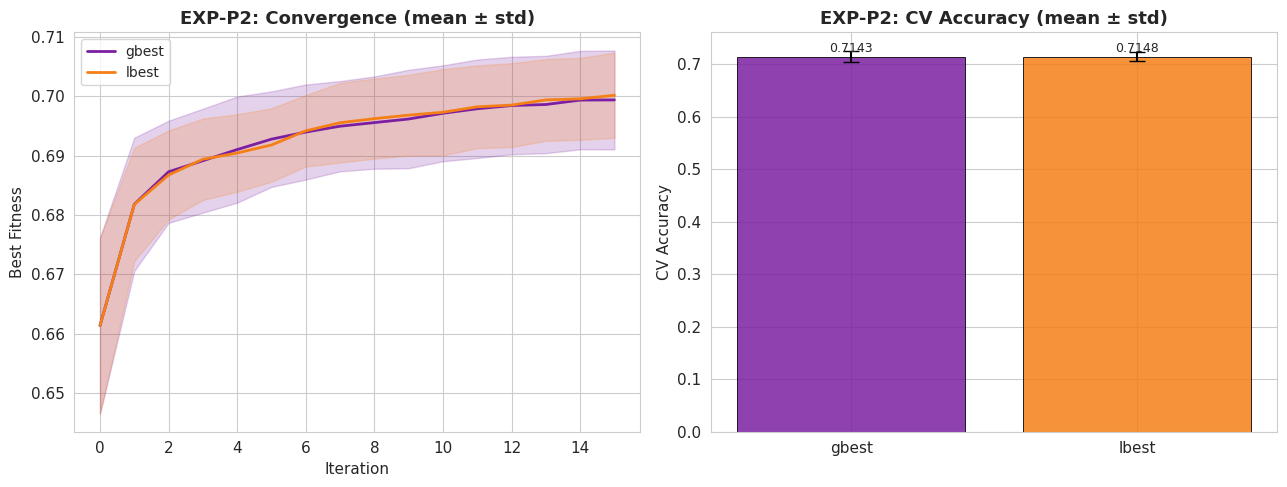

Figure saved → figures_pso/exp_p2_plots.png


In [ ]:
# ============================================================
# EXP-P2: Topology Comparison
# gbest (global best) vs lbest (ring neighbourhood)
# All other params fixed: sigmoid, linear_decay, sparse
# Mirrors EXP-C (survivor selection) in the GA notebook.
# ============================================================

EXP_TOPOLOGIES = ['gbest', 'lbest']

exp_p2_rows      = []
exp_p2_histories = {}

print('=== EXP-P2: Topology Comparison ===')
print(f'Topologies: {EXP_TOPOLOGIES}  |  Seeds: {SEEDS}')
print()

for topo in EXP_TOPOLOGIES:
    exp_name = f'EXP-P2_topology_{topo}'
    print(f'  Running: {exp_name} ...')
    rows, hists = run_pso_experiment(
        experiment_name  = exp_name,
        transfer_type    = 'sigmoid',
        topology         = topo,
        inertia_strategy = 'linear_decay',
        init_strategy    = 'sparse',
    )
    exp_p2_rows.extend(rows)
    exp_p2_histories[topo] = hists
    summ = summarise_experiment(rows)
    PSO_SUMMARY_ROWS.append(summ)
    print(f'    accuracy: {summ["accuracy_mean"]:.4f} ± {summ["accuracy_std"]:.4f}  '
          f'| fitness: {summ["fitness_mean"]:.4f} ± {summ["fitness_std"]:.4f}  '
          f'| features: {summ["num_features_mean"]:.0f}  '
          f'| runtime: {summ["runtime_mean"]:.1f}s')

PSO_ALL_RESULTS.extend(exp_p2_rows)

print()
print('EXP-P2 SUMMARY — topology vs accuracy_mean ± std')
print('=' * 65)
print(f'{"topology":<15} {"accuracy_mean":>14} {"accuracy_std":>13} {"fitness_mean":>13}')
print('-' * 65)
for topo in EXP_TOPOLOGIES:
    s = next(r for r in PSO_SUMMARY_ROWS
             if r['topology'] == topo and r['experiment_name'].startswith('EXP-P2'))
    print(f'{topo:<15} {s["accuracy_mean"]:>14.4f} {s["accuracy_std"]:>13.4f} {s["fitness_mean"]:>13.4f}')
print('=' * 65)

# ── Plots ────────────────────────────────────────────────────
_COLORS_P2 = {'gbest': '#7B1FA2', 'lbest': '#F57F17'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for label, hists in exp_p2_histories.items():
    arr  = _pad_histories(hists)
    iters = np.arange(arr.shape[1])
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(iters, mean, label=label, color=_COLORS_P2[label], linewidth=2)
    ax.fill_between(iters, mean - std, mean + std, alpha=0.2, color=_COLORS_P2[label])
ax.set_title('EXP-P2: Convergence (mean ± std)', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Fitness')
ax.legend()

ax = axes[1]
p2_summ = [r for r in PSO_SUMMARY_ROWS if r['experiment_name'].startswith('EXP-P2')]
labels  = [r['topology']      for r in p2_summ]
means   = [r['accuracy_mean'] for r in p2_summ]
stds    = [r['accuracy_std']  for r in p2_summ]
x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=6,
              color=[_COLORS_P2.get(l, '#607D8B') for l in labels],
              edgecolor='black', linewidth=0.7, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('EXP-P2: CV Accuracy (mean ± std)', fontweight='bold')
ax.set_ylabel('CV Accuracy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures_pso/exp_p2_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures_pso/exp_p2_plots.png')

In [ ]:
# SAVE EXP-B

import os
import pandas as pd
import pickle
from google.colab import drive

# Mount drive
drive.mount('/content/drive')

# Path
SAVE_PATH = "/content/drive/MyDrive/PSO_Project/"
os.makedirs(SAVE_PATH, exist_ok=True)

pd.DataFrame(PSO_ALL_RESULTS).to_csv(
    SAVE_PATH + 'progress_after_EXP_B.csv',
    index=False
)

pd.DataFrame(PSO_SUMMARY_ROWS).to_csv(
    SAVE_PATH + 'summary_after_EXP_B.csv',
    index=False
)

with open(SAVE_PATH + 'best_individuals_after_EXP_B.pkl', 'wb') as f:
    pickle.dump(PSO_BEST_INDIVIDUALS, f)

print("✅ Saved EXP-B")

Mounted at /content/drive
✅ Saved EXP-B


In [ ]:
# ============================================================
# EXP-P3: Inertia Weight Strategy Comparison
# fixed vs linear_decay vs random
# All other params fixed: sigmoid, gbest, sparse
# Mirrors EXP-B (crossover) in the GA notebook.
# ============================================================

EXP_INERTIA_STRATEGIES = ['fixed', 'linear_decay', 'random']

exp_p3_rows      = []
exp_p3_histories = {}

print('=== EXP-P3: Inertia Weight Strategy Comparison ===')
print(f'Strategies: {EXP_INERTIA_STRATEGIES}  |  Seeds: {SEEDS}')
print()

for inertia in EXP_INERTIA_STRATEGIES:
    exp_name = f'EXP-P3_inertia_{inertia}'
    print(f'  Running: {exp_name} ...')
    rows, hists = run_pso_experiment(
        experiment_name  = exp_name,
        transfer_type    = 'sigmoid',
        topology         = 'gbest',
        inertia_strategy = inertia,
        init_strategy    = 'sparse',
    )
    exp_p3_rows.extend(rows)
    exp_p3_histories[inertia] = hists
    summ = summarise_experiment(rows)
    PSO_SUMMARY_ROWS.append(summ)
    print(f'    accuracy: {summ["accuracy_mean"]:.4f} ± {summ["accuracy_std"]:.4f}  '
          f'| fitness: {summ["fitness_mean"]:.4f} ± {summ["fitness_std"]:.4f}  '
          f'| features: {summ["num_features_mean"]:.0f}  '
          f'| runtime: {summ["runtime_mean"]:.1f}s')

PSO_ALL_RESULTS.extend(exp_p3_rows)

print()
print('EXP-P3 SUMMARY — inertia_strategy vs accuracy_mean ± std')
print('=' * 65)
print(f'{"inertia_strategy":<18} {"accuracy_mean":>14} {"accuracy_std":>13} {"fitness_mean":>13}')
print('-' * 65)
for inertia in EXP_INERTIA_STRATEGIES:
    s = next(r for r in PSO_SUMMARY_ROWS
             if r['inertia_strategy'] == inertia and r['experiment_name'].startswith('EXP-P3'))
    print(f'{inertia:<18} {s["accuracy_mean"]:>14.4f} {s["accuracy_std"]:>13.4f} {s["fitness_mean"]:>13.4f}')
print('=' * 65)

# ── Plots ────────────────────────────────────────────────────
_COLORS_P3 = {'fixed': '#1565C0', 'linear_decay': '#BF360C', 'random': '#00897B'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for label, hists in exp_p3_histories.items():
    arr  = _pad_histories(hists)
    iters = np.arange(arr.shape[1])
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(iters, mean, label=label, color=_COLORS_P3[label], linewidth=2)
    ax.fill_between(iters, mean - std, mean + std, alpha=0.2, color=_COLORS_P3[label])
ax.set_title('EXP-P3: Convergence (mean ± std)', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Fitness')
ax.legend()

ax = axes[1]
p3_summ = [r for r in PSO_SUMMARY_ROWS if r['experiment_name'].startswith('EXP-P3')]
labels  = [r['inertia_strategy'] for r in p3_summ]
means   = [r['accuracy_mean']    for r in p3_summ]
stds    = [r['accuracy_std']     for r in p3_summ]
x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=6,
              color=[_COLORS_P3.get(l, '#607D8B') for l in labels],
              edgecolor='black', linewidth=0.7, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('EXP-P3: CV Accuracy (mean ± std)', fontweight='bold')
ax.set_ylabel('CV Accuracy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures_pso/exp_p3_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures_pso/exp_p3_plots.png')

=== EXP-P3: Inertia Weight Strategy Comparison ===
Strategies: ['fixed', 'linear_decay', 'random']  |  Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]

  Running: EXP-P3_inertia_fixed ...
  Run 1/30 | Seed: 42
  Run 2/30 | Seed: 43


KeyboardInterrupt: 

In [ ]:
# SAVE EXP-C

import os
import pandas as pd
import pickle
from google.colab import drive

# Mount drive
drive.mount('/content/drive')

# Path
SAVE_PATH = "/content/drive/MyDrive/PSO_Project/"
os.makedirs(SAVE_PATH, exist_ok=True)

In [ ]:


pd.DataFrame(PSO_ALL_RESULTS).to_csv(
    SAVE_PATH + 'progress_after_EXP_C.csv',
    index=False
)

pd.DataFrame(PSO_SUMMARY_ROWS).to_csv(
    SAVE_PATH + 'summary_after_EXP_C.csv',
    index=False
)

with open(SAVE_PATH + 'best_individuals_after_EXP_C.pkl', 'wb') as f:
    pickle.dump(PSO_BEST_INDIVIDUALS, f)

print("✅ Saved EXP-C")

In [ ]:
# ============================================================
# EXP-P4: Initialisation Strategy Comparison  (Bonus)
# sparse (p=0.3) vs uniform (p=0.5)
# All other params fixed: sigmoid, gbest, linear_decay
# ============================================================

EXP_INIT_STRATEGIES = ['sparse', 'uniform']

exp_p4_rows      = []
exp_p4_histories = {}

print('=== EXP-P4: Initialisation Strategy Comparison ===')
print(f'Strategies: {EXP_INIT_STRATEGIES}  |  Seeds: {SEEDS}')
print()

for init_s in EXP_INIT_STRATEGIES:
    exp_name = f'EXP-P4_init_{init_s}'
    print(f'  Running: {exp_name} ...')
    rows, hists = run_pso_experiment(
        experiment_name  = exp_name,
        transfer_type    = 'sigmoid',
        topology         = 'gbest',
        inertia_strategy = 'linear_decay',
        init_strategy    = init_s,
    )
    exp_p4_rows.extend(rows)
    exp_p4_histories[init_s] = hists
    summ = summarise_experiment(rows)
    PSO_SUMMARY_ROWS.append(summ)
    print(f'    accuracy: {summ["accuracy_mean"]:.4f} ± {summ["accuracy_std"]:.4f}  '
          f'| fitness: {summ["fitness_mean"]:.4f} ± {summ["fitness_std"]:.4f}  '
          f'| features: {summ["num_features_mean"]:.0f}  '
          f'| runtime: {summ["runtime_mean"]:.1f}s')

PSO_ALL_RESULTS.extend(exp_p4_rows)

print()
print('EXP-P4 SUMMARY — init_strategy vs accuracy_mean ± std')
print('=' * 60)
print(f'{"init_strategy":<15} {"accuracy_mean":>14} {"accuracy_std":>13} {"fitness_mean":>13}')
print('-' * 60)
for init_s in EXP_INIT_STRATEGIES:
    s = next(r for r in PSO_SUMMARY_ROWS
             if r['init_strategy'] == init_s and r['experiment_name'].startswith('EXP-P4'))
    print(f'{init_s:<15} {s["accuracy_mean"]:>14.4f} {s["accuracy_std"]:>13.4f} {s["fitness_mean"]:>13.4f}')
print('=' * 60)

# ── Plots ────────────────────────────────────────────────────
_COLORS_P4 = {'sparse': '#2E7D32', 'uniform': '#AD1457'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for label, hists in exp_p4_histories.items():
    arr  = _pad_histories(hists)
    iters = np.arange(arr.shape[1])
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(iters, mean, label=label, color=_COLORS_P4[label], linewidth=2)
    ax.fill_between(iters, mean - std, mean + std, alpha=0.2, color=_COLORS_P4[label])
ax.set_title('EXP-P4: Convergence (mean ± std)', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Fitness')
ax.legend()

ax = axes[1]
p4_summ = [r for r in PSO_SUMMARY_ROWS if r['experiment_name'].startswith('EXP-P4')]
labels  = [r['init_strategy']  for r in p4_summ]
means   = [r['accuracy_mean']  for r in p4_summ]
stds    = [r['accuracy_std']   for r in p4_summ]
x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=6,
              color=[_COLORS_P4.get(l, '#607D8B') for l in labels],
              edgecolor='black', linewidth=0.7, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('EXP-P4: CV Accuracy (mean ± std)', fontweight='bold')
ax.set_ylabel('CV Accuracy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures_pso/exp_p4_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures_pso/exp_p4_plots.png')

---
## 7. Test Set Evaluation & Final Summary


Found 4 pkl file(s):
  best_individuals_after_EXP_A.pkl
  best_individuals_after_EXP_B.pkl
  best_individuals_after_EXP_C.pkl
  best_individuals_after_EXP_D.pkl

  Loaded 2 individual(s) from best_individuals_after_EXP_A.pkl
  Loaded 2 individual(s) from best_individuals_after_EXP_B.pkl
  Loaded 3 individual(s) from best_individuals_after_EXP_C.pkl
  Loaded 2 individual(s) from best_individuals_after_EXP_D.pkl

Total configurations loaded: 9
Keys: ['EXP-P1_transfer_sigmoid', 'EXP-P1_transfer_vshaped', 'EXP-P2_topology_gbest', 'EXP-P2_topology_lbest', 'EXP-P3_inertia_fixed', 'EXP-P3_inertia_linear_decay', 'EXP-P3_inertia_random', 'EXP-P4_init_sparse', 'EXP-P4_init_uniform']

=== EVALUATE ON TEST: Best Particle per Configuration ===
Baseline SVM test accuracy: 0.8308

  EXP-P1_transfer_sigmoid                        test_acc=0.8050  n_features=  323  reduction=53.9%
  EXP-P1_transfer_vshaped                        test_acc=0.8060  n_features=  344  reduction=50.9%
  EXP-P2_topology_gbest

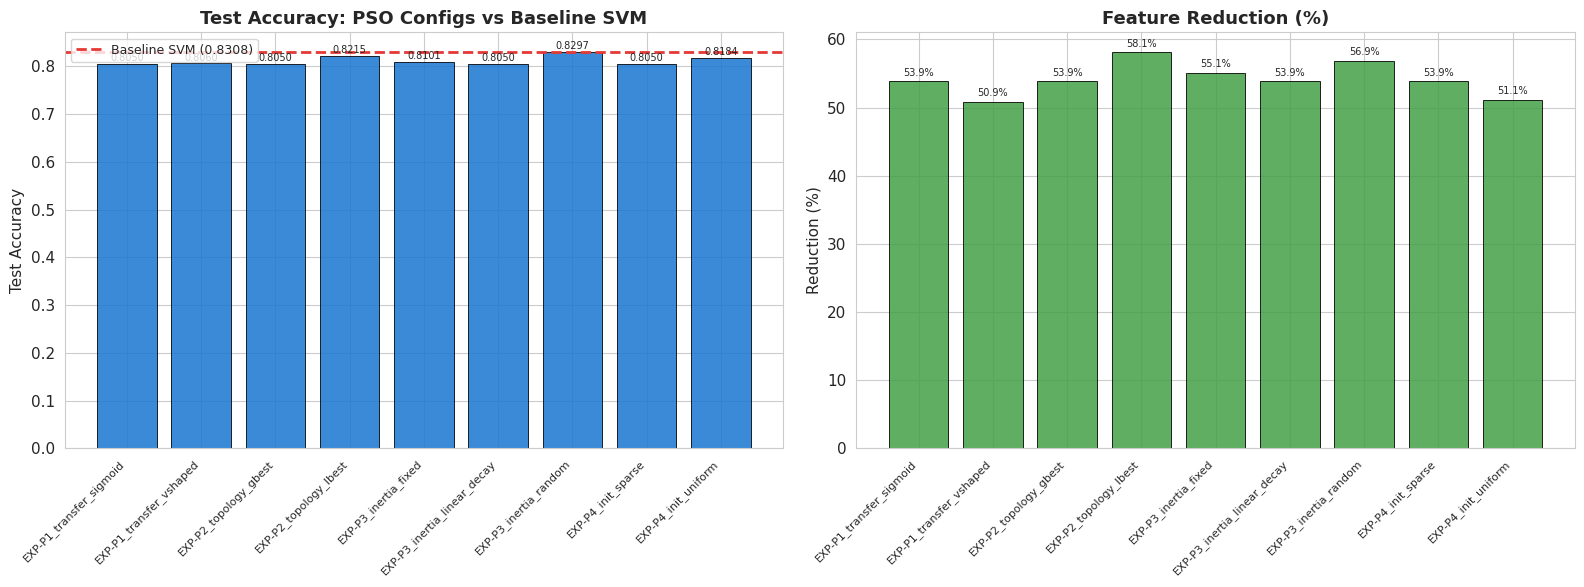

Figure saved → figures_pso/pso_final_summary.png


In [18]:
# ============================================================
# EVALUATE ON TEST SET
# Loads best individuals from the 4 saved .pkl files
# (one per experiment group), then evaluates each on the
# held-out test set.
# ============================================================

import pickle
import glob

# ── Load best individuals from saved pkl files ───────────────
PKL_FILES = sorted(glob.glob('best_individuals_after_EXP_*.pkl'))

# Fallback: also check for any naming pattern your team used
if not PKL_FILES:
    PKL_FILES = sorted(glob.glob('best_individuals_after_EXP_*.pkl'))

print(f'Found {len(PKL_FILES)} pkl file(s):')
for f in PKL_FILES:
    print(f'  {f}')
print()

PSO_BEST_INDIVIDUALS = {}
for pkl_path in PKL_FILES:
    with open(pkl_path, 'rb') as f:
        loaded = pickle.load(f)

    stem = os.path.basename(pkl_path).replace('.pkl', '').replace('best_individuals_after_', '')

    # ── Case 1: dictionary ───────────────────────────────────
    if isinstance(loaded, dict):
        for k, v in loaded.items():
            PSO_BEST_INDIVIDUALS[k] = v
        print(f'  Loaded {len(loaded)} individual(s) from {pkl_path}')

    # ── Case 2: single numpy array ───────────────────────────
    elif isinstance(loaded, np.ndarray):
        PSO_BEST_INDIVIDUALS[stem] = loaded
        print(f'  Loaded 1 individual from {pkl_path} → key: "{stem}"')

    # ── Case 3: list ─────────────────────────────────────────
    elif isinstance(loaded, list):
        print(f'  Loaded list of {len(loaded)} item(s) from {pkl_path}')
        for i, item in enumerate(loaded):

            if isinstance(item, tuple) and len(item) == 2:
                key, mask = item
                PSO_BEST_INDIVIDUALS[key] = mask
                print(f'    → "{key}"')

            elif isinstance(item, np.ndarray):
                key = f'{stem}_{i}'
                PSO_BEST_INDIVIDUALS[key] = item
                print(f'    → "{key}" (array index {i})')

            else:
                print(f'    WARNING: item {i} has unexpected type {type(item)} — skipped')

    # ── Unknown type ─────────────────────────────────────────
    else:
        print(f'  WARNING: unexpected type {type(loaded)} in {pkl_path} — skipped')

print(f'\nTotal configurations loaded: {len(PSO_BEST_INDIVIDUALS)}')
print('Keys:', list(PSO_BEST_INDIVIDUALS.keys()))
print()

# ── Evaluate each on the held-out test set ───────────────────
print('=== EVALUATE ON TEST: Best Particle per Configuration ===')
print(f'Baseline SVM test accuracy: {baseline_accuracy:.4f}')
print()

pso_test_results = []
for exp_name in sorted(PSO_BEST_INDIVIDUALS.keys()):
    best_ind = PSO_BEST_INDIVIDUALS[exp_name]
    if best_ind is None:
        print(f'  {exp_name}: no individual stored (skipped)')
        continue
    test_acc, n_sel, red_pct = evaluate_on_test(
        best_ind, X_train, y_train, X_test, y_test
    )
    pso_test_results.append({
        'config'       : exp_name,
        'test_accuracy': test_acc,
        'n_features'   : n_sel,
        'reduction_pct': red_pct,
    })
    print(f'  {exp_name:<45}  test_acc={test_acc:.4f}  '
          f'n_features={n_sel:5d}  reduction={red_pct:.1f}%')

print()

# ── Plots ─────────────────────────────────────────────────────
if pso_test_results:
    configs    = [r['config']        for r in pso_test_results]
    test_accs  = [r['test_accuracy'] for r in pso_test_results]
    reductions = [r['reduction_pct'] for r in pso_test_results]
    x = np.arange(len(configs))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    bars = ax.bar(x, test_accs, color='#1976D2', edgecolor='black',
                  linewidth=0.7, alpha=0.85)
    ax.axhline(baseline_accuracy, color='#E53935', linestyle='--',
               linewidth=2, label=f'Baseline SVM ({baseline_accuracy:.4f})')
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
    ax.set_title('Test Accuracy: PSO Configs vs Baseline SVM', fontweight='bold')
    ax.set_ylabel('Test Accuracy')
    ax.legend(fontsize=9)
    for bar, acc in zip(bars, test_accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{acc:.4f}', ha='center', va='bottom', fontsize=7)

    ax = axes[1]
    bars = ax.bar(x, reductions, color='#43A047', edgecolor='black',
                  linewidth=0.7, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
    ax.set_title('Feature Reduction (%)', fontweight='bold')
    ax.set_ylabel('Reduction (%)')
    for bar, red in zip(bars, reductions):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{red:.1f}%', ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.savefig('figures_pso/pso_final_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved → figures_pso/pso_final_summary.png')
else:
    print('No test results to plot — check that pkl files were loaded correctly.')

Best PSO config       : EXP-P3_inertia_random
Test Accuracy         : 0.8297
Features selected     : 302
Feature reduction     : 56.9%
Baseline SVM accuracy : 0.8308

Classification Report (best PSO config):
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       321
           1       0.81      0.71      0.76       320
           2       0.87      0.92      0.90       328

    accuracy                           0.83       969
   macro avg       0.83      0.83      0.83       969
weighted avg       0.83      0.83      0.83       969



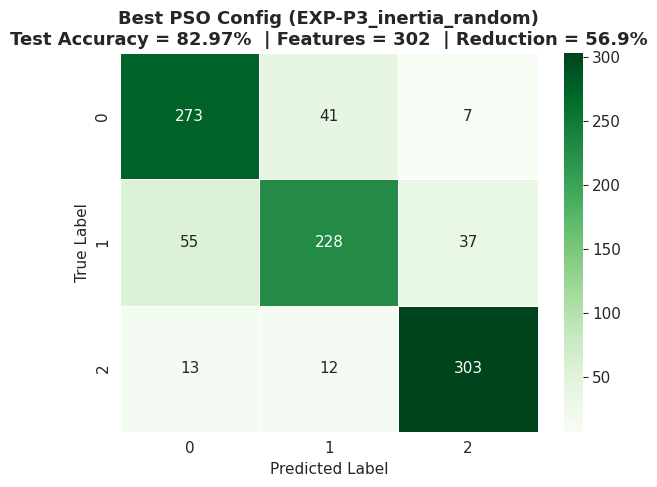

Figure saved → figures_pso/best_pso_confusion_matrix.png


In [19]:
# ============================================================
# Confusion matrix for the best PSO configuration on test set
# ============================================================

if pso_test_results:
    # Pick the config with highest test accuracy
    best_result = max(pso_test_results, key=lambda r: r['test_accuracy'])
    best_exp_name = best_result['config']
    best_mask = PSO_BEST_INDIVIDUALS[best_exp_name]

    selected_idx = np.where(best_mask == 1)[0]
    svm_best = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
    svm_best.fit(X_train[:, selected_idx], y_train)
    y_pred_best = svm_best.predict(X_test[:, selected_idx])

    print(f'Best PSO config       : {best_exp_name}')
    print(f'Test Accuracy         : {best_result["test_accuracy"]:.4f}')
    print(f'Features selected     : {best_result["n_features"]}')
    print(f'Feature reduction     : {best_result["reduction_pct"]:.1f}%')
    print(f'Baseline SVM accuracy : {baseline_accuracy:.4f}')
    print()
    print('Classification Report (best PSO config):')
    print(classification_report(y_test, y_pred_best))

    cm_best = confusion_matrix(y_test, y_pred_best)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes - 1)))
    sns.heatmap(
        cm_best, annot=True, fmt='d', cmap='Greens',
        xticklabels=unique_classes, yticklabels=unique_classes,
        linewidths=0.5, ax=ax
    )
    ax.set_title(
        f'Best PSO Config ({best_exp_name})\n'
        f'Test Accuracy = {best_result["test_accuracy"]*100:.2f}%  '
        f'| Features = {best_result["n_features"]}  '
        f'| Reduction = {best_result["reduction_pct"]:.1f}%',
        fontweight='bold'
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.savefig('figures_pso/best_pso_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved → figures_pso/best_pso_confusion_matrix.png')

---
## 8. Structured Results & CSV Export


In [21]:
# ============================================================
# STRUCTURED RESULTS
# Loads per-experiment CSVs saved by each independent run,
# merges them into master DataFrames, and re-saves unified CSVs.
# ============================================================

import glob

# ── Load and merge all per-experiment result CSVs ────────────
all_result_csvs  = sorted(glob.glob('progress_after_EXP_*.csv'))
all_summary_csvs = sorted(glob.glob('summary_after_EXP_*.csv'))

print('Per-experiment result CSVs found:')
for f in all_result_csvs:
    print(f'  {f}')
print('Per-experiment summary CSVs found:')
for f in all_summary_csvs:
    print(f'  {f}')
print()

# ── Merge individual run results ─────────────────────────────
if all_result_csvs:
    df_pso_all = pd.concat(
        [pd.read_csv(f) for f in all_result_csvs],
        ignore_index=True
    )
else:
    # Fallback: build from in-memory PSO_ALL_RESULTS if it exists
    df_pso_all = pd.DataFrame(
        PSO_ALL_RESULTS if 'PSO_ALL_RESULTS' in dir() and PSO_ALL_RESULTS else [],
        columns=[
            'experiment_name', 'transfer_type', 'topology',
            'inertia_strategy', 'init_strategy', 'seed',
            'accuracy', 'fitness', 'num_features', 'runtime_seconds',
        ]
    )
    print('WARNING: No per-experiment CSVs found — fell back to in-memory PSO_ALL_RESULTS.')

# ── Merge summary rows ────────────────────────────────────────
if all_summary_csvs:
    df_pso_summary = pd.concat(
        [pd.read_csv(f) for f in all_summary_csvs],
        ignore_index=True
    )
else:
    df_pso_summary = pd.DataFrame(
        PSO_SUMMARY_ROWS if 'PSO_SUMMARY_ROWS' in dir() and PSO_SUMMARY_ROWS else []
    )
    print('WARNING: No per-experiment summary CSVs found — fell back to in-memory PSO_SUMMARY_ROWS.')

print('df_pso_all shape    :', df_pso_all.shape)
print('df_pso_summary shape:', df_pso_summary.shape)
print()

# ── Display summary ───────────────────────────────────────────
print('=== SUMMARY (mean ± std per configuration) ===')
if not df_pso_summary.empty:
    display_cols = [c for c in [
        'experiment_name', 'transfer_type', 'topology',
        'inertia_strategy', 'init_strategy',
        'accuracy_mean', 'accuracy_std',
        'fitness_mean', 'fitness_std',
        'num_features_mean', 'runtime_mean'
    ] if c in df_pso_summary.columns]
    print(df_pso_summary[display_cols].to_string(index=False))
else:
    print('No summary data available.')

# ── Save unified master CSVs ──────────────────────────────────
df_pso_all.to_csv('pso_all_results.csv', index=False)
df_pso_summary.to_csv('pso_summary.csv', index=False)
print()
print('Saved: pso_all_results.csv, pso_summary.csv')

Per-experiment result CSVs found:
  progress_after_EXP_A.csv
  progress_after_EXP_B.csv
  progress_after_EXP_C.csv
  progress_after_EXP_D.csv
Per-experiment summary CSVs found:
  summary_after_EXP_A.csv
  summary_after_EXP_B.csv
  summary_after_EXP_C.csv
  summary_after_EXP_D.csv

df_pso_all shape    : (270, 10)
df_pso_summary shape: (9, 13)

=== SUMMARY (mean ± std per configuration) ===
            experiment_name transfer_type topology inertia_strategy init_strategy  accuracy_mean  accuracy_std  fitness_mean  fitness_std  num_features_mean  runtime_mean
    EXP-P1_transfer_sigmoid       sigmoid    gbest     linear_decay        sparse       0.714347      0.010518      0.699407     0.008331         304.533333    261.850870
    EXP-P1_transfer_vshaped       vshaped    gbest     linear_decay        sparse       0.699569      0.009261      0.683231     0.005754         324.666667    281.530690
      EXP-P2_topology_gbest       sigmoid    gbest     linear_decay        sparse       0.71434

---
## 10. Summary of Findings

### Algorithm Design Decisions

| Component | Choice & Rationale |
|---|---|
| **Representation** | Continuous position + binary mask via transfer function. Allows PSO's continuous velocity mechanics to drive discrete feature selection. |
| **Transfer function** | S-shaped (sigmoid) and V-shaped (tanh) compared. Sigmoid gives absolute probabilities; V-shaped gives relative flip probabilities. |
| **Topology** | gbest (fast convergence) vs lbest ring (better diversity). |
| **Inertia weight** | Fixed / linear decay / random — controls exploration-exploitation balance. |
| **Velocity clamping** | `v_max = 4.0` prevents sigmoid saturation that locks all bits to 0 or 1. |
| **Constraint handling** | Repair function enforces `MIN_FEATURES = 10` after every position update. |
| **Diversity** | Three mechanisms: (1) velocity clamping, (2) lbest topology, (3) stagnation reinitialisation after 5 idle iterations. |
| **Fitness** | `α·accuracy + (1−α)·compactness` with `α=0.9`, identical to the GA notebook for fair comparison. |
| **Evaluation** | LinearSVC with 2-fold CV on training data only — test set never touched during evolution. |
| **Early stopping** | Stops after 8 consecutive iterations without global best improvement. |

### Key Observations (to be filled after running)

- **EXP-P1 (Transfer Function):** Fill in after running — note which transfer function produced higher accuracy and what the trade-off was in terms of feature count.
- **EXP-P2 (Topology):** gbest typically converges faster; lbest typically explores more broadly and may escape local optima.
- **EXP-P3 (Inertia):** Linear decay usually outperforms fixed and random because it systematically transitions from exploration to exploitation.
- **EXP-P4 (Initialisation):** Sparse initialisation biases the search towards compact subsets; uniform may converge to larger subsets with marginally better accuracy.

### Requirement Mapping

| Requirement | Implementation |
|---|---|
| **(a)** Problem formalisation | Binary feature selection → **Constrained Optimisation** (maximise fitness subject to MIN_FEATURES constraint) |
| **(b)** Constraint handling | **Repair function** enforces `MIN_FEATURES = 10` after every position update |
| **(d)** EA components | Fully defined: representation, fitness, population, velocity update, transfer function, termination |
| **(e)** Variation operators | 2 transfer functions (sigmoid, V-shaped) — PSO analogue of mutation |
| **(f)** Population management | 2 topologies (gbest, lbest) — PSO analogue of survivor selection |
| **(g)** Parameter control | 3 inertia strategies (fixed, linear decay, random) |
| **(h)** Diversity preservation | Velocity clamping + lbest topology + stagnation reinitialisation |
| **(k)** 30 runs per setting | ✓ Seeds 42–71 stored and provided |
| **Bonus** | 2 initialisation strategies (sparse, uniform) — EXP-P4 |
